# Visualization of Voice Directivity Data


Import all required packages

In [ ]:
%matplotlib widget
import pyfar as pf
import matplotlib.pyplot as plt
import spharpy
import sofar
import numpy as np
import pooch

Download the directivity data from Zenodo via pooch. The data is provided as a zip file, which needs to be extracted. The zip file contains a total of 13 directivity measurements. Each directivity and the corresponding positions at which it is captured is contained in a sofa file.

In [ ]:
from pathlib import Path
from zipfile import ZipFile

fname_directivity = pooch.retrieve(
    url="doi:10.5281/zenodo.7834210/Voice_Directivity_sentence.zip",
    known_hash="md5:521446f7cacd11261f6fd1bfd59ae40b",
)

with ZipFile(fname_directivity) as zip_file:
    zip_file.extractall(Path(fname_directivity).parent)

Open the sofa file

In [ ]:
fname_sofa = Path(fname_directivity).parent / "DirectivitySentence_13_upsampled.sofa"
directivity, _, sampling_grid = pf.io.read_sofa(fname_sofa)

Store the spatial sampling grid in a `SamplingSphere` object.

In [ ]:
sampling_grid = spharpy.SamplingSphere.from_cartesian(
    np.squeeze(sampling_grid.x),
    np.squeeze(sampling_grid.y),
    np.squeeze(sampling_grid.z)
)

Create a wireframe balloon visualization of the directivity data.

In [ ]:
freq_index = directivity.find_nearest_frequency(2000)
plt.figure()
spharpy.plot.balloon_wireframe(
    sampling_grid,
    np.squeeze(directivity.freq[..., freq_index]),
)
plt.show()

Visualize as a map projection.

In [ ]:
plt.figure()
spharpy.plot.pcolor_map(
    sampling_grid,
    20*np.log10(np.abs(np.squeeze(directivity.freq[..., freq_index]))),
    cmap="viridis",
)
plt.show()

# License notice
This notebook © 2026 by Marco Berzborn and Christoph Pörschmann is licensed under [CC BY 4.0](http://creativecommons.org/licenses/by/4.0/?ref=chooser-v1)

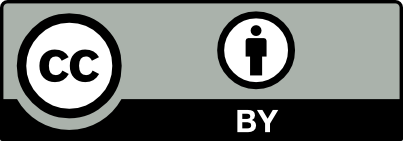

# Watermark

In [ ]:
%load_ext watermark
%watermark -v -m -iv